# 🛡️ Detección de Fraude — Reclamaciones de Seguros
## Proyecto de Machine Learning | Python · scikit-learn · matplotlib

**Objetivo:** Identificar reclamaciones de seguros fraudulentas antes de su aprobación.

| Dato | Valor |
|---|---|
| Registros | 30,000 reclamaciones |
| Tasa de fraude | ~12 % |
| Modelos | Logistic Regression · Random Forest · Gradient Boosting |


## 0. Setup

In [1]:
%matplotlib inline
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, average_precision_score, precision_recall_curve, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
os.makedirs("reports/figures", exist_ok=True)

COLORS = {
    "bg": "#0D1117", "panel": "#161B22", "accent": "#F7B731",
    "red": "#FF4B6E", "blue": "#4B9FFF", "green": "#00D4AA",
    "text": "#E6EDF3", "muted": "#8B949E",
}
plt.rcParams.update({
    "figure.facecolor": COLORS["bg"],   "axes.facecolor":  COLORS["panel"],
    "axes.edgecolor":   COLORS["muted"],"axes.labelcolor": COLORS["text"],
    "xtick.color":      COLORS["muted"],"ytick.color":     COLORS["muted"],
    "text.color":       COLORS["text"], "grid.color":      "#21262D",
    "grid.linestyle":   "--",
})
print("✅ Setup completo")

✅ Setup completo


## 1. Generación de datos sintéticos

In [2]:
CLAIM_TYPES  = ["auto","health","home","life"]
REGIONS      = ["norte","sur","este","oeste","centro"]
OCCUPATIONS  = ["empleado","independiente","jubilado","desempleado"]

def generate_insurance_data(n_samples=30_000):
    fraud_ratio = 0.12
    n_fraud = int(n_samples * fraud_ratio)
    n_legit = n_samples - n_fraud

    legit = pd.DataFrame({
        "claim_amount":      np.random.lognormal(8.0, 1.0, n_legit),
        "policy_duration_y": np.random.uniform(0.5, 20, n_legit),
        "n_prev_claims":     np.random.poisson(0.8, n_legit),
        "days_to_report":    np.random.exponential(5, n_legit).astype(int),
        "claim_type":        np.random.choice(CLAIM_TYPES, n_legit),
        "region":            np.random.choice(REGIONS, n_legit),
        "occupation":        np.random.choice(OCCUPATIONS, n_legit, p=[0.55,0.25,0.15,0.05]),
        "age":               np.random.randint(18, 75, n_legit),
        "n_witnesses":       np.random.poisson(1.2, n_legit),
        "police_report":     np.random.binomial(1, 0.60, n_legit),
        "label": 0,
    })
    fraud = pd.DataFrame({
        "claim_amount":      np.random.lognormal(9.5, 1.3, n_fraud),
        "policy_duration_y": np.random.uniform(0.1, 3, n_fraud),
        "n_prev_claims":     np.random.poisson(3.5, n_fraud),
        "days_to_report":    np.random.exponential(20, n_fraud).astype(int),
        "claim_type":        np.random.choice(CLAIM_TYPES, n_fraud, p=[0.40,0.15,0.30,0.15]),
        "region":            np.random.choice(REGIONS, n_fraud),
        "occupation":        np.random.choice(OCCUPATIONS, n_fraud, p=[0.20,0.35,0.05,0.40]),
        "age":               np.random.randint(20, 50, n_fraud),
        "n_witnesses":       np.random.poisson(0.3, n_fraud),
        "police_report":     np.random.binomial(1, 0.25, n_fraud),
        "label": 1,
    })
    df = pd.concat([legit, fraud], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

    # Feature engineering
    le = LabelEncoder()
    for col in ["claim_type","region","occupation"]:
        df[col] = le.fit_transform(df[col])
    df["amount_log"]       = np.log1p(df["claim_amount"])
    df["low_policy_age"]   = (df["policy_duration_y"] < 1).astype(int)
    df["high_prev_claims"] = (df["n_prev_claims"] >= 3).astype(int)
    df["late_report"]      = (df["days_to_report"] > 15).astype(int)
    df["no_witnesses"]     = (df["n_witnesses"] == 0).astype(int)
    return df

df = generate_insurance_data(30_000)
print(f"✅ Dataset generado: {len(df):,} reclamaciones")
print(f"   Fraude: {df['label'].sum():,} ({df['label'].mean()*100:.2f}%)")
df.head()

✅ Dataset generado: 30,000 reclamaciones
   Fraude: 3,600 (12.00%)


,claim_amount,policy_duration_y,n_prev_claims,days_to_report,claim_type,region,occupation,age,n_witnesses,police_report,label,amount_log,low_policy_age,high_prev_claims,late_report,no_witnesses
0,5087.315931,16.351473,1,9,2,3,1,64,2,1,0,8.534702,0,0,0,0
1,13527.172589,6.525293,0,23,0,3,1,50,1,1,0,9.512530,0,0,1,0
2,4839.101002,16.829836,1,1,1,1,2,70,0,0,0,8.484691,0,0,0,1
3,6631.052701,2.501847,1,0,3,4,2,18,2,0,0,8.799670,0,0,0,0
4,4737.222593,13.953885,0,0,3,4,3,60,1,1,0,8.463417,0,0,0,0


## 2. Análisis Exploratorio (EDA)

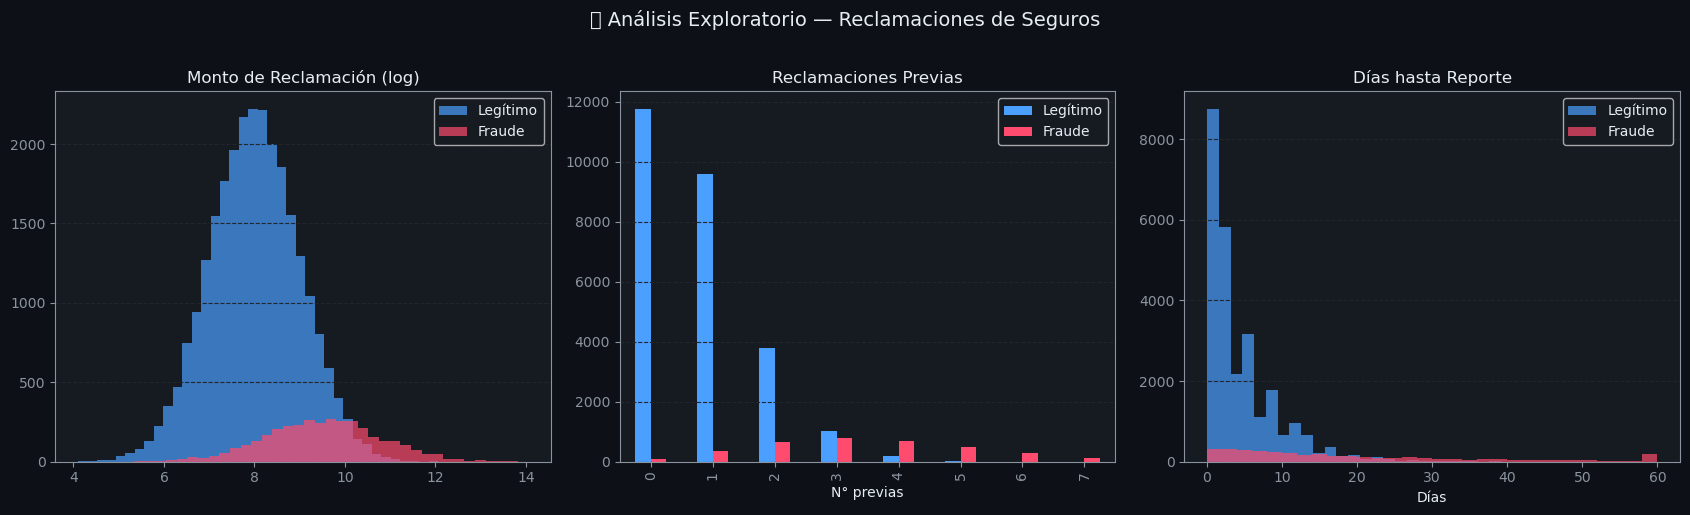

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Distribución de montos
for label, col, lbl in [(0, COLORS["blue"],"Legítimo"),(1, COLORS["red"],"Fraude")]:
    axes[0].hist(np.log1p(df[df["label"]==label]["claim_amount"]),
                 bins=40, alpha=0.7, color=col, label=lbl, edgecolor="none")
axes[0].set_title("Monto de Reclamación (log)"); axes[0].legend(); axes[0].grid(axis="y")

# Reclamaciones previas
ct = df.groupby(["n_prev_claims","label"]).size().unstack(fill_value=0).head(8)
ct.plot(kind="bar", ax=axes[1], color=[COLORS["blue"],COLORS["red"]], edgecolor="none")
axes[1].set_title("Reclamaciones Previas"); axes[1].set_xlabel("N° previas")
axes[1].legend(["Legítimo","Fraude"], facecolor=COLORS["panel"]); axes[1].grid(axis="y")

# Días hasta reporte
for label, col, lbl in [(0, COLORS["blue"],"Legítimo"),(1, COLORS["red"],"Fraude")]:
    data = df[df["label"]==label]["days_to_report"].clip(upper=60)
    axes[2].hist(data, bins=30, alpha=0.7, color=col, label=lbl, edgecolor="none")
axes[2].set_title("Días hasta Reporte"); axes[2].set_xlabel("Días")
axes[2].legend(); axes[2].grid(axis="y")

plt.suptitle("🛡️ Análisis Exploratorio — Reclamaciones de Seguros", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("reports/figures/insurance_claim_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Preprocesamiento y balanceo

In [4]:
FEATURES = [
    "amount_log","policy_duration_y","n_prev_claims","days_to_report",
    "claim_type","region","occupation","age","n_witnesses",
    "police_report","low_policy_age","high_prev_claims","late_report","no_witnesses",
]

X = df[FEATURES]; y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

df_tmp     = pd.concat([X_train, y_train], axis=1)
minority   = df_tmp[df_tmp["label"]==1]
majority   = df_tmp[df_tmp["label"]==0]
minority_up= resample(minority, replace=True, n_samples=len(majority)//3, random_state=SEED)
df_bal     = pd.concat([majority, minority_up])
X_res, y_res = df_bal.drop("label", axis=1), df_bal["label"]

print(f"Train original : {len(X_train):,} | Fraude: {y_train.sum()}")
print(f"Train balanceado: {len(X_res):,}  | Fraude: {y_res.sum()}")
print(f"Test           : {len(X_test):,}  | Fraude: {y_test.sum()}")

Train original : 24,000 | Fraude: 2880
Train balanceado: 28,160  | Fraude: 7040
Test           : 6,000  | Fraude: 720


## 4. Entrenamiento de modelos

In [5]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", max_depth=10, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=SEED),
}

results = {}
for name, model in models.items():
    print(f"\n⏳ Entrenando {name}...")
    model.fit(X_res, y_res)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "model": model, "y_pred": y_pred, "y_proba": y_proba,
        "roc_auc":  roc_auc_score(y_test, y_proba),
        "avg_prec": average_precision_score(y_test, y_proba),
        "f1":       f1_score(y_test, y_pred),
    }
    print(f"   ROC-AUC : {results[name]['roc_auc']:.4f}")
    print(f"   Avg Prec: {results[name]['avg_prec']:.4f}")
    print(f"   F1 Score: {results[name]['f1']:.4f}")

best_name = max(results, key=lambda k: results[k]["roc_auc"])
print(f"\n✅ Todos los modelos entrenados | 🏆 Mejor: {best_name}")


⏳ Entrenando Logistic Regression...
   ROC-AUC : 0.9986
   Avg Prec: 0.9903
   F1 Score: 0.9159

⏳ Entrenando Random Forest...
   ROC-AUC : 0.9991
   Avg Prec: 0.9935
   F1 Score: 0.9446

⏳ Entrenando Gradient Boosting...
   ROC-AUC : 0.9993
   Avg Prec: 0.9953
   F1 Score: 0.9651

✅ Todos los modelos entrenados | 🏆 Mejor: Gradient Boosting


## 5. Evaluación — Reporte de Clasificación

In [6]:
for name, res in results.items():
    print(f"\n📊 {name}")
    print(classification_report(y_test, res["y_pred"], target_names=["Legítimo","Fraude"]))


📊 Logistic Regression
              precision    recall  f1-score   support

    Legítimo       1.00      0.98      0.99      5280
      Fraude       0.85      0.99      0.92       720

    accuracy                           0.98      6000
   macro avg       0.93      0.98      0.95      6000
weighted avg       0.98      0.98      0.98      6000


📊 Random Forest
              precision    recall  f1-score   support

    Legítimo       1.00      0.99      0.99      5280
      Fraude       0.91      0.98      0.94       720

    accuracy                           0.99      6000
   macro avg       0.95      0.98      0.97      6000
weighted avg       0.99      0.99      0.99      6000


📊 Gradient Boosting
              precision    recall  f1-score   support

    Legítimo       1.00      0.99      1.00      5280
      Fraude       0.95      0.98      0.97       720

    accuracy                           0.99      6000
   macro avg       0.97      0.99      0.98      6000
weighted avg 

## 6. Visualizaciones

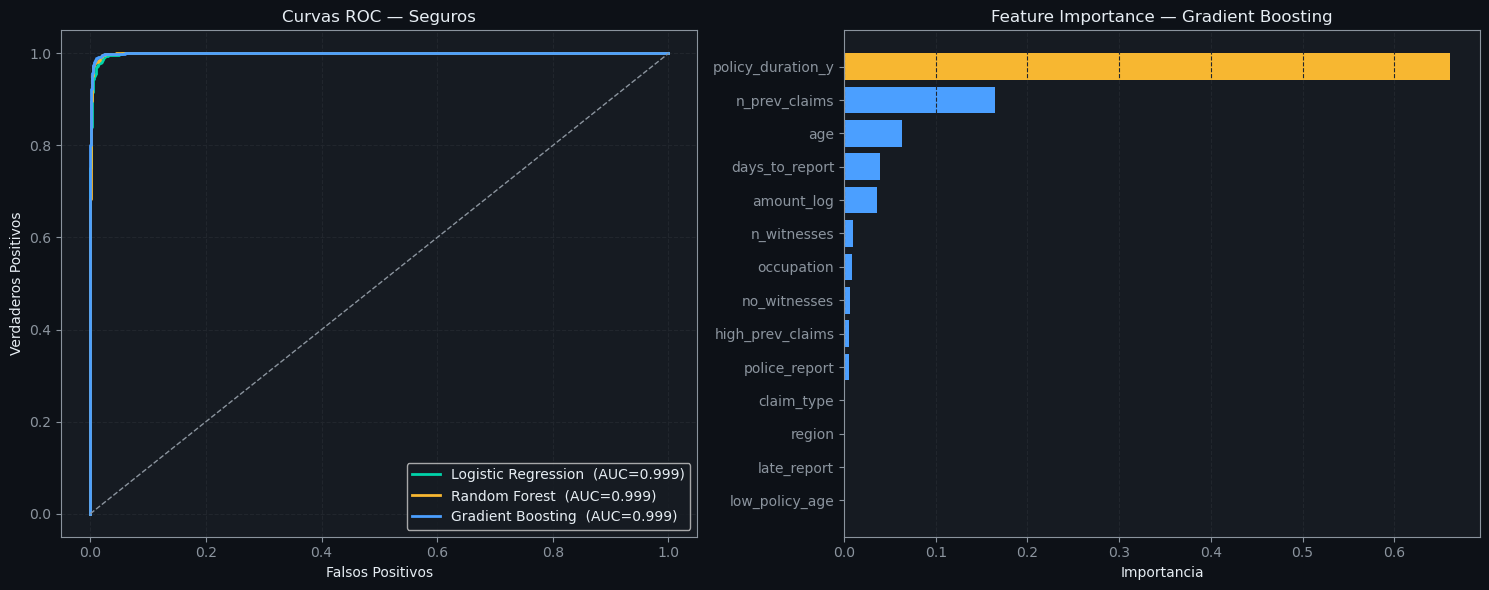

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = [COLORS["green"], COLORS["accent"], COLORS["blue"]]

# ROC Curves
for (name, res), col in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    axes[0].plot(fpr, tpr, label=f"{name}  (AUC={res['roc_auc']:.3f})", color=col, lw=2)
axes[0].plot([0,1],[0,1],"--",color=COLORS["muted"],lw=1)
axes[0].set_title("Curvas ROC — Seguros"); axes[0].set_xlabel("Falsos Positivos")
axes[0].set_ylabel("Verdaderos Positivos"); axes[0].legend(facecolor=COLORS["panel"])
axes[0].grid(True)

# Feature Importance
gb_model = results["Gradient Boosting"]["model"]
imp = pd.Series(gb_model.feature_importances_, index=FEATURES).sort_values()
colors_fi = [COLORS["accent"] if v == imp.max() else COLORS["blue"] for v in imp.values]
axes[1].barh(imp.index, imp.values, color=colors_fi, edgecolor="none")
axes[1].set_title("Feature Importance — Gradient Boosting"); axes[1].set_xlabel("Importancia")
axes[1].grid(axis="x")

plt.tight_layout()
plt.savefig("reports/figures/insurance_roc_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Matriz de Confusión

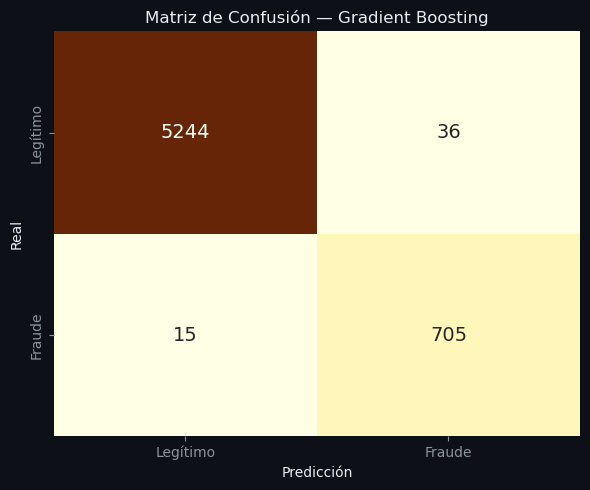

In [8]:
cm = confusion_matrix(y_test, results[best_name]["y_pred"])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr",
            xticklabels=["Legítimo","Fraude"], yticklabels=["Legítimo","Fraude"],
            ax=ax, cbar=False, annot_kws={"size":14})
ax.set_title(f"Matriz de Confusión — {best_name}")
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig("reports/figures/insurance_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Resumen Final

In [10]:
summary = pd.DataFrame({
    "Modelo":   list(results.keys()),
    "ROC-AUC":  [f"{v['roc_auc']:.4f}"  for v in results.values()],
    "Avg Prec": [f"{v['avg_prec']:.4f}" for v in results.values()],
    "F1-Score": [f"{v['f1']:.4f}"       for v in results.values()],
})
print("🏆 RESULTADOS FINALES — Reclamaciones de Seguros")
print("=" * 55)
display(summary)
print(f"\n✅ Mejor modelo: {best_name} | ROC-AUC = {results[best_name]['roc_auc']:.4f}")

🏆 RESULTADOS FINALES — Reclamaciones de Seguros


,Modelo,ROC-AUC,Avg Prec,F1-Score
0,Logistic Regression,0.9986,0.9903,0.9159
1,Random Forest,0.9991,0.9935,0.9446
2,Gradient Boosting,0.9993,0.9953,0.9651



✅ Mejor modelo: Gradient Boosting | ROC-AUC = 0.9993
